# CATER Analysis Notebook

This notebook analyzes the experimental results for CATER and Random Search (RS) reported in the repository artifacts.

Run it from the repository root, or from a subdirectory inside the repository. The notebook locates the repository root automatically and expects the `scenario-*` result folders to be present there.

The proposed approach is named CATER in the paper. Some generated files still use the legacy `GA` directory and file-name prefix; the constants below keep that mapping explicit.

## Dependencies and setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, rankdata

In [2]:
SCENARIO_CONFIG = {
    1: {"route": "route_4", "n_tests": 20},
    2: {"route": "route_2", "n_tests": 20},
    3: {"route": "route_5", "n_tests": 20},
}

# CATER is the proposed approach. The experimental data uses GA folder and file names for backward compatibility.
CATER_LABEL = "CATER"
CATER_DATA_DIR = "GA"
RS_LABEL = "RS"

PERFORMANCE_COLUMNS = [
    "scenario",
    "test",
    "eval_id",
    "time_to_reach_goal",
    "time_not_moving",
    "fitness",
]

PERFORMANCE_METRICS = {
    "Time to Reach Goal (s)": "time_to_reach_goal",
    "Time Not Moving (s)": "time_not_moving",
}

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
})

## Helper functions

### Path utilities

In [3]:
def find_repo_root(start: Path) -> Path:

    project_markers = ["README.md", "src"]

    for p in [start] + list(start.parents):
        has_project_markers = all((p / marker).exists() for marker in project_markers)
        has_git_or_data = (p / ".git").exists() or any(
            (p / f"scenario-{scenario_id}").exists()
            for scenario_id in SCENARIO_CONFIG
        )

        if has_project_markers and has_git_or_data:
            return p

    raise RuntimeError(
        f"Repository root not found. Checked from: {start}"
    )

REPO_ROOT = find_repo_root(Path.cwd())


def scenario_dir(scenario_id: int) -> Path:
    return REPO_ROOT / f"scenario-{scenario_id}"


def get_search_summary_path(scenario_id: int, approach_data_dir: str, test_num: int) -> Path:
    return (
        scenario_dir(scenario_id)
        / approach_data_dir
        / f"test-{test_num}"
        / "search_summary.csv"
    )


def get_cater_evaluations_path(scenario_id: int, test_num: int) -> Path:
    route = SCENARIO_CONFIG[scenario_id]["route"]
    return (
        scenario_dir(scenario_id)
        / CATER_DATA_DIR
        / f"test-{test_num}"
        / "algorithm_trace"
        / f"GA_{route}"
        / "ga_evaluations.csv"
    )


def get_cater_privacy_log_path(scenario_id: int, test_num: int, eval_id: int) -> Path:
    route = SCENARIO_CONFIG[scenario_id]["route"]
    return (
        scenario_dir(scenario_id)
        / CATER_DATA_DIR
        / f"test-{test_num}"
        / "privacy"
        / route
        / str(eval_id)
        / "log.csv"
    )

### Data loading

In [4]:
def read_csv_required(path: Path, required_columns: list[str]) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

    df = pd.read_csv(path)

    missing_columns = sorted(set(required_columns) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing columns {missing_columns} in {path}")

    return df


def load_privacy_violation_durations(scenario_id: int, approach_data_dir: str) -> np.ndarray:
    values = []
    n_tests = SCENARIO_CONFIG[scenario_id]["n_tests"]

    for test_num in range(1, n_tests + 1):
        path = get_search_summary_path(scenario_id, approach_data_dir, test_num)
        df = read_csv_required(path, ["best_privacy_violation_duration"])
        values.append(df["best_privacy_violation_duration"].iloc[0])

    return np.asarray(values, dtype=float)


def load_performance_data_for_test(scenario_id: int, test_num: int) -> pd.DataFrame:
    cater_evaluations_path = get_cater_evaluations_path(scenario_id, test_num)
    df_cater = read_csv_required(cater_evaluations_path, ["eval_id", "fitness"])

    df_cater = df_cater[df_cater["fitness"] != 0.0].copy()

    rows = []

    for _, row in df_cater.iterrows():
        eval_id = int(row["eval_id"])
        log_path = get_cater_privacy_log_path(scenario_id, test_num, eval_id)

        if not log_path.exists():
            continue

        df_log = read_csv_required(log_path, ["time_to_reach_goal", "time_not_moving"])

        rows.append({
            "scenario": scenario_id,
            "test": test_num,
            "eval_id": eval_id,
            "time_to_reach_goal": df_log["time_to_reach_goal"].iloc[0],
            "time_not_moving": df_log["time_not_moving"].iloc[0],
            "fitness": row["fitness"],
        })

    return pd.DataFrame(rows, columns=PERFORMANCE_COLUMNS)


def load_performance_data_for_scenario(scenario_id: int) -> dict:
    n_tests = SCENARIO_CONFIG[scenario_id]["n_tests"]

    test_frames = {
        test_num: load_performance_data_for_test(scenario_id, test_num)
        for test_num in range(1, n_tests + 1)
    }

    non_empty_frames = [df for df in test_frames.values() if not df.empty]
    all_data = (
        pd.concat(non_empty_frames, ignore_index=True)
        if non_empty_frames
        else pd.DataFrame(columns=PERFORMANCE_COLUMNS)
    )

    return {
        "tests": test_frames,
        "all": all_data,
    }

### Statistical utilities

In [5]:
def iqr(values) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.nan

    return np.percentile(values, 75) - np.percentile(values, 25)


def format_mean_sd(values, precision=3) -> str:
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return "NA"

    mean = np.mean(values)
    sd = np.std(values, ddof=1) if len(values) > 1 else np.nan

    if np.isnan(sd):
        return f"{mean:.{precision}f} ± NA"

    return f"{mean:.{precision}f} ± {sd:.{precision}f}"


def vargha_delaney_a12(x, y) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0 or len(y) == 0:
        raise ValueError("Vargha-Delaney A12 requires two non-empty samples.")

    all_values = np.concatenate([x, y])
    ranks = rankdata(all_values)
    ranks_x = ranks[:len(x)]

    n1 = len(x)
    n2 = len(y)
    rank_sum_x = np.sum(ranks_x)

    return (rank_sum_x - n1 * (n1 + 1) / 2) / (n1 * n2)


def descriptive_stats(values, label: str) -> dict:
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        raise ValueError(f"No values available for {label}.")

    mean = np.mean(values)
    sd = np.std(values, ddof=1) if len(values) > 1 else np.nan

    return {
        "Approach": label,
        "Min": np.min(values),
        "Max": np.max(values),
        "Median": np.median(values),
        "IQR": iqr(values),
        "Mean": mean,
        "SD": sd,
        "Mean $\\pm$ sd": format_mean_sd(values, precision=3),
    }


def build_statistical_report(x, y, method_x=CATER_LABEL, method_y=RS_LABEL) -> pd.DataFrame:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    _, p_value = mannwhitneyu(x, y, alternative="two-sided")
    a12 = vargha_delaney_a12(x, y)

    stats_x = descriptive_stats(x, method_x)
    stats_y = descriptive_stats(y, method_y)

    report = pd.DataFrame([
        {
            "Approach": stats_x["Approach"],
            "Min": stats_x["Min"],
            "Max": stats_x["Max"],
            "Median": stats_x["Median"],
            "IQR": stats_x["IQR"],
            "Mean $\\pm$ sd": stats_x["Mean $\\pm$ sd"],
            "p-value": p_value,
            "A12": a12,
        },
        {
            "Approach": stats_y["Approach"],
            "Min": stats_y["Min"],
            "Max": stats_y["Max"],
            "Median": stats_y["Median"],
            "IQR": stats_y["IQR"],
            "Mean $\\pm$ sd": stats_y["Mean $\\pm$ sd"],
            "p-value": p_value,
            "A12": a12,
        },
    ])

    return report

### Table utilities

In [6]:
def sample_sd(values) -> float:
    values = np.asarray(values, dtype=float)
    return np.std(values, ddof=1) if len(values) > 1 else 0.0


def build_rq2_table(scenarios):
    rows = []

    for scenario_id in scenarios:
        values = load_privacy_violation_durations(scenario_id, CATER_DATA_DIR)
        values = np.asarray(values, dtype=float)

        stats = descriptive_stats(values, CATER_LABEL)

        rows.append({
            "Scenario": f"S{scenario_id}",
            "Min": stats["Min"],
            "Max": stats["Max"],
            "Median": stats["Median"],
            "IQR": stats["IQR"],
            "Mean $\\pm$ sd": stats["Mean $\\pm$ sd"],
        })

    return pd.DataFrame(rows).round({
        "Min": 2,
        "Max": 2,
        "Median": 2,
        "IQR": 2,
    })


def summarize_performance_by_test(performance_data: dict, test_ids=None) -> pd.DataFrame:
    test_frames = performance_data["tests"]

    if test_ids is None:
        test_ids = sorted(test_frames.keys())

    rows = []

    for metric_label, column in PERFORMANCE_METRICS.items():
        for statistic in ["Min", "Max", "Avg"]:
            row = {
                "Metric": metric_label,
                "Statistic": statistic,
            }

            for test_id in test_ids:
                df = test_frames[test_id]
                values = df[column].dropna()

                if statistic == "Min":
                    value = values.min()
                elif statistic == "Max":
                    value = values.max()
                else:
                    value = values.mean()

                row[str(test_id)] = value

            rows.append(row)

    table = pd.DataFrame(rows)
    table = table.set_index(["Metric", "Statistic"])

    return table.round(2)


def summarize_performance_by_scenario(scenario_frames: dict) -> pd.DataFrame:
    rows = []

    for scenario_label, df in scenario_frames.items():
        for metric_label, column in PERFORMANCE_METRICS.items():
            values = df[column].dropna()

            rows.append({
                "Scenario": scenario_label,
                "Metric": metric_label,
                "Min": values.min(),
                "Max": values.max(),
                "Mean $\\pm$ sd": format_mean_sd(values, precision=2),
                "Median": values.median(),
                "IQR": iqr(values),
            })

    return pd.DataFrame(rows).round({
        "Min": 2,
        "Max": 2,
        "Median": 2,
        "IQR": 2,
    })

### Plotting utilities

In [7]:
def plot_boxplot(data, labels, ylabel, figsize=(3, 4)):
    n_boxes = len(data)

    positions = 1.0 + np.arange(n_boxes) * 0.5

    fig, ax = plt.subplots(figsize=figsize)

    ax.boxplot(
        data,
        positions=positions,
        widths=0.3,
        tick_labels=labels,
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_xlim(positions[0] - 0.35, positions[-1] + 0.35)

    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    fig.tight_layout()
    plt.show()

# RQ-1

**How effective is the CATER compared to Random Search in generating tests that expose privacy requirement violations?**

## Scenario 1

In [8]:
cater_s1 = load_privacy_violation_durations(1, CATER_DATA_DIR)
rs_s1 = load_privacy_violation_durations(1, RS_LABEL)

privacy_duration_data = pd.DataFrame({
    CATER_LABEL: cater_s1,
    RS_LABEL: rs_s1,
})

privacy_duration_data

,CATER,RS
0,3.521841,3.007288
1,20.017333,4.034192
2,11.575297,3.964702
3,4.026593,3.980667
4,4.043298,4.528097
5,3.034340,5.550967
6,3.037544,4.040710
7,3.539957,6.000673
8,3.530563,4.544073
9,5.049696,5.501568


### Distribution of best privacy violation duration

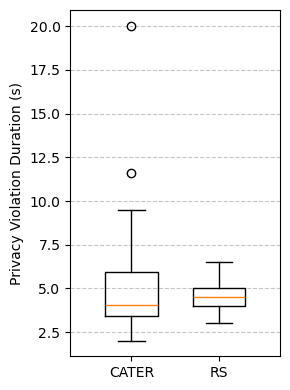

In [9]:
plot_boxplot(
    data=[cater_s1, rs_s1],
    labels=[CATER_LABEL, RS_LABEL],
    ylabel="Privacy Violation Duration (s)",
)

In [10]:
s1_report = build_statistical_report(cater_s1, rs_s1)

s1_report = s1_report.round({
    "Median": 2,
    "IQR": 2,
    "p-value": 5,
    "A12": 3,
})

s1_report

,Approach,Min,Max,Median,IQR,Mean $\pm$ sd,p-value,A12
0,CATER,2.025304,20.017333,4.03,2.53,5.483 ± 4.221,0.49033,0.435
1,RS,3.007288,6.504735,4.53,1.03,4.590 ± 0.851,0.49033,0.435


## Scenario 2

In [11]:
cater_s2 = load_privacy_violation_durations(2, CATER_DATA_DIR)
rs_s2 = load_privacy_violation_durations(2, RS_LABEL)

privacy_duration_data = pd.DataFrame({
    CATER_LABEL: cater_s2,
    RS_LABEL: rs_s2,
})

privacy_duration_data

,CATER,RS
0,4.956696,4.545991
1,7.575797,10.062219
2,7.587155,7.990095
3,7.602999,7.590358
4,7.594590,6.988296
5,7.578619,7.558235
6,7.586170,6.061308
7,7.546872,6.061597
8,7.964200,6.959065
9,14.512585,6.049582


### Distribution of best privacy violation duration

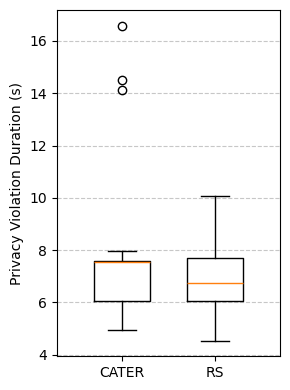

In [12]:
plot_boxplot(
    data=[cater_s2, rs_s2],
    labels=[CATER_LABEL, RS_LABEL],
    ylabel="Privacy Violation Duration (s)",
    figsize=(3, 4),
)

In [13]:
s2_report = build_statistical_report(cater_s2, rs_s2)

s2_report = s2_report.round({
    "Median": 2,
    "IQR": 2,
    "p-value": 5,
    "A12": 3,
})

s2_report

,Approach,Min,Max,Median,IQR,Mean $\pm$ sd,p-value,A12
0,CATER,4.956696,16.578553,7.56,1.56,7.978 ± 3.200,0.90312,0.488
1,RS,4.545991,10.062219,6.76,1.63,7.007 ± 1.246,0.90312,0.488


## Scenario 3

In [14]:
cater_rq1 = load_privacy_violation_durations(3, CATER_DATA_DIR)
rs_rq1 = load_privacy_violation_durations(3, RS_LABEL)

privacy_duration_data = pd.DataFrame({
    CATER_LABEL: cater_rq1,
    RS_LABEL: rs_rq1,
})

privacy_duration_data

,CATER,RS
0,25.575059,7.971623
1,10.560936,8.535790
2,16.054788,8.062105
3,12.082484,7.577857
4,8.565939,9.003218
5,25.521205,7.954189
6,8.050024,8.520244
7,7.548845,7.472873
8,19.016274,9.089872
9,7.074478,10.984681


### Distribution of best privacy violation duration

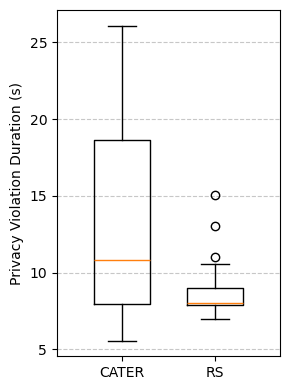

In [15]:
plot_boxplot(
    data=[cater_rq1, rs_rq1],
    labels=[CATER_LABEL, RS_LABEL],
    ylabel="Privacy Violation Duration (s)",
    figsize=(3, 4),
)

In [16]:
rq1_report = build_statistical_report(cater_rq1, rs_rq1)

rq1_report = rq1_report.round({
    "Median": 2,
    "IQR": 2,
    "p-value": 5,
    "A12": 3,
})

rq1_report

,Approach,Min,Max,Median,IQR,Mean $\pm$ sd,p-value,A12
0,CATER,5.575690,26.076497,10.84,10.73,13.761 ± 7.212,0.04986,0.682
1,RS,6.988438,15.031607,8.05,1.16,8.918 ± 2.032,0.04986,0.682


# RQ-2

**How do different navigation routes affect the effectiveness of generated tests in revealing privacy violations?**

In [17]:
rq2_table = build_rq2_table([1, 2, 3])

In [18]:
scenario_labels = ["Scenario 1", "Scenario 2", "Scenario 3"]

cater_by_scenario = {
    scenario_id: load_privacy_violation_durations(scenario_id, CATER_DATA_DIR)
    for scenario_id in SCENARIO_CONFIG
}

In [19]:
rq2_table[[
    "Scenario",
    "Min",
    "Max",
    "Median",
    "IQR",
    "Mean $\\pm$ sd",
]]

,Scenario,Min,Max,Median,IQR,Mean $\pm$ sd
0,S1,2.03,20.02,4.03,2.53,5.483 ± 4.221
1,S2,4.96,16.58,7.56,1.56,7.978 ± 3.200
2,S3,5.58,26.08,10.84,10.73,13.761 ± 7.212


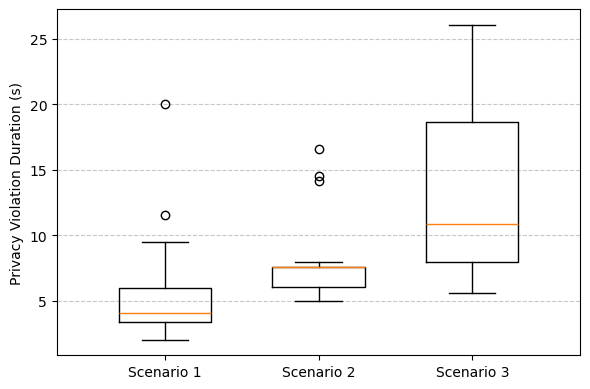

In [20]:
plot_boxplot(
    data=[
        cater_by_scenario[scenario_id]
        for scenario_id in SCENARIO_CONFIG
    ],
    labels=scenario_labels,
    ylabel="Privacy Violation Duration (s)",
    figsize=(6, 4),
)

# RQ-3

**What is the impact of privacy violations on system performance?**

### Load performance data

This section loads valid evaluations with non-zero fitness and extracts:
- `time_to_reach_goal`
- `time_not_moving`

In [21]:
performance_s1 = load_performance_data_for_scenario(1)
performance_s2 = load_performance_data_for_scenario(2)
performance_s3 = load_performance_data_for_scenario(3)

df_s1 = performance_s1["all"]
df_s2 = performance_s2["all"]
df_s3 = performance_s3["all"]

In [22]:
performance_summary = summarize_performance_by_scenario({
    "Scenario 1": df_s1,
    "Scenario 2": df_s2,
    "Scenario 3": df_s3,
})

performance_summary

,Scenario,Metric,Min,Max,Mean $\pm$ sd,Median,IQR
0,Scenario 1,Time to Reach Goal (s),20.88,35.03,27.77 ± 3.34,29.48,6.80
1,Scenario 1,Time Not Moving (s),0.00,1.49,0.31 ± 0.28,0.50,0.50
2,Scenario 2,Time to Reach Goal (s),18.81,35.03,23.65 ± 2.86,21.91,5.45
3,Scenario 2,Time Not Moving (s),0.00,1.01,0.30 ± 0.26,0.50,0.50
4,Scenario 3,Time to Reach Goal (s),19.87,35.03,23.68 ± 1.47,23.31,1.25
5,Scenario 3,Time Not Moving (s),0.00,26.02,0.33 ± 0.46,0.50,0.50


In [23]:
scenario1_performance_table = summarize_performance_by_test(performance_s1)
scenario1_performance_table

1      2      3      4      5      6  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        20.88  22.10  22.22  22.35  21.91  22.16   
                       Max        28.02  35.03  32.21  27.06  25.21  26.06   
                       Avg        23.67  25.05  25.00  23.86  23.82  23.68   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         0.99   1.49   1.49   0.99   0.99   0.99   
                       Avg         0.35   0.33   0.38   0.39   0.37   0.36   

                                      7      8      9     10     11     12  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        21.91  22.33  21.91  25.83  24.86  25.77   
                       Max        26.16  25.16  25.16  35.01  32.08  33.21   
                       Avg        24.35  24.07  23.88  30.70  30.49  30.69   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         0.99   0.99   0.99   1.00   1.00   1.01   
                       Avg         0.36   0.34   0.39   0.26   0.28   0.27   

                                     13     14     15     16     17     18  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        24.86  24.81  26.16  25.15  24.93  25.77   
                       Max        33.32  35.03  33.56  32.15  33.73  34.82   
                       Avg        30.58  30.37  30.94  30.21  30.09  30.61   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         1.00   1.00   1.00   1.00   1.01   1.00   
                       Avg         0.26   0.28   0.28   0.28   0.27   0.27   

                                     19     20  
Metric                 Statistic                
Time to Reach Goal (s) Min        24.73  24.90  
                       Max        35.03  31.97  
                       Avg        30.72  29.28  
Time Not Moving (s)    Min         0.00   0.00  
                       Max         1.00   1.00  
                       Avg         0.25   0.29

In [24]:
scenario2_performance_table = summarize_performance_by_test(performance_s2)
scenario2_performance_table

1      2      3      4      5      6  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        19.65  24.90  24.10  22.59  23.12  20.26   
                       Max        25.02  28.67  30.61  34.76  28.29  28.27   
                       Avg        21.44  26.51  26.53  26.67  26.60  26.43   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         1.00   0.99   0.99   0.99   1.00   1.01   
                       Avg         0.32   0.27   0.26   0.29   0.27   0.27   

                                      7      8      9     10     11     12  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        23.68  24.62  22.64  24.59  19.20  19.21   
                       Max        29.67  30.88  29.61  35.03  22.66  23.21   
                       Avg        26.91  26.53  26.36  27.24  21.00  21.06   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         0.99   0.99   0.99   1.00   0.99   0.99   
                       Avg         0.26   0.29   0.28   0.29   0.32   0.34   

                                     13     14     15     16     17     18  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        19.08  19.19  19.03  19.13  18.81  19.03   
                       Max        23.91  22.77  22.96  22.61  33.81  31.65   
                       Avg        20.94  20.70  21.11  21.07  21.81  21.32   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         0.99   0.99   1.00   0.99   0.99   0.99   
                       Avg         0.35   0.32   0.33   0.33   0.33   0.34   

                                     19     20  
Metric                 Statistic                
Time to Reach Goal (s) Min        18.99  19.23  
                       Max        24.01  32.09  
                       Avg        21.19  21.27  
Time Not Moving (s)    Min         0.00   0.00  
                       Max         0.99   0.99  
                       Avg         0.32   0.30

In [25]:
scenario3_performance_table = summarize_performance_by_test(performance_s3)
scenario3_performance_table

1      2      3      4      5      6  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        20.41  20.76  21.06  21.31  19.87  20.30   
                       Max        35.03  35.02  32.11  30.71  35.03  35.03   
                       Avg        23.80  24.05  23.51  24.02  23.71  24.82   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         1.00  26.02   1.01   1.48  10.66   1.50   
                       Avg         0.32   0.43   0.34   0.33   0.37   0.34   

                                      7      8      9     10     11     12  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        21.17  21.72  21.21  21.15  21.55  20.83   
                       Max        25.96  25.71  35.03  35.03  24.21  32.81   
                       Avg        23.38  23.70  23.69  23.71  22.93  23.54   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         0.99   1.00   1.00   1.01   0.99   0.99   
                       Avg         0.34   0.33   0.33   0.32   0.33   0.32   

                                     13     14     15     16     17     18  \
Metric                 Statistic                                             
Time to Reach Goal (s) Min        20.35  21.16  20.64  20.50  21.41  20.00   
                       Max        26.06  27.56  29.97  34.08  24.36  35.02   
                       Avg        23.54  23.64  23.65  23.40  23.00  23.70   
Time Not Moving (s)    Min         0.00   0.00   0.00   0.00   0.00   0.00   
                       Max         0.99   0.99   1.00   0.99   0.99   0.99   
                       Avg         0.32   0.34   0.31   0.32   0.35   0.29   

                                     19     20  
Metric                 Statistic                
Time to Reach Goal (s) Min        20.95  20.59  
                       Max        35.02  34.10  
                       Avg        23.66  23.85  
Time Not Moving (s)    Min         0.00   0.00  
                       Max         0.99   0.99  
                       Avg         0.32   0.30

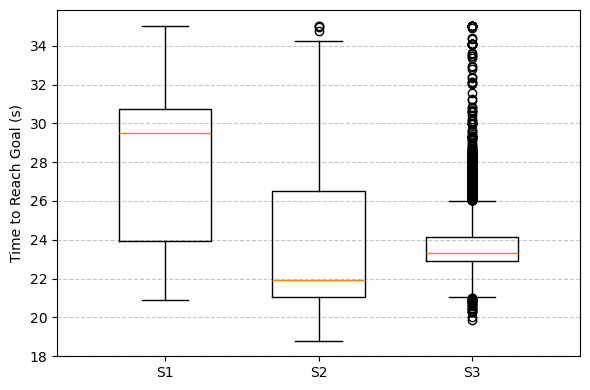

In [26]:
plot_boxplot(
    data=[
        df_s1["time_to_reach_goal"],
        df_s2["time_to_reach_goal"],
        df_s3["time_to_reach_goal"],
    ],
    labels=["S1", "S2", "S3"],
    ylabel="Time to Reach Goal (s)",
    figsize=(6, 4),
)

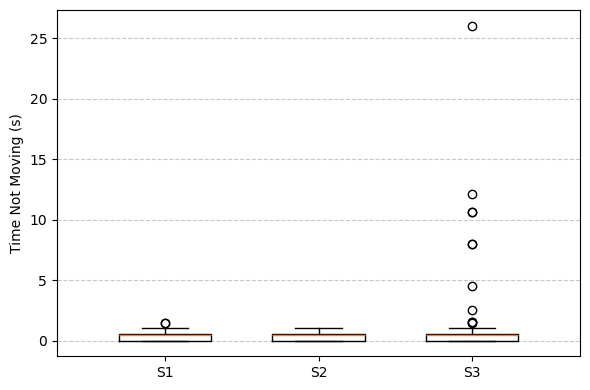

In [27]:
plot_boxplot(
    data=[
        df_s1["time_not_moving"],
        df_s2["time_not_moving"],
        df_s3["time_not_moving"],
    ],
    labels=["S1", "S2", "S3"],
    ylabel="Time Not Moving (s)",
    figsize=(6, 4),
)